In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())


Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [4]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)

print("Data Cleaning Completed!")


Data Cleaning Completed!


/tmp/ipython-input-1238756707.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [5]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


In [6]:
df = pd.get_dummies(df, drop_first=True)

print("Encoding Completed!")
print(df.shape)


Encoding Completed!
(7043, 31)


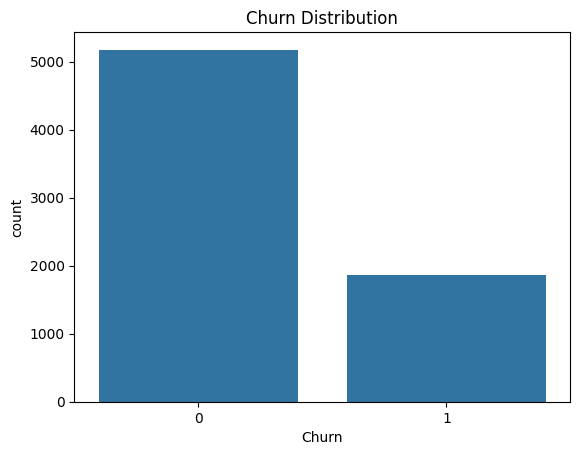

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()



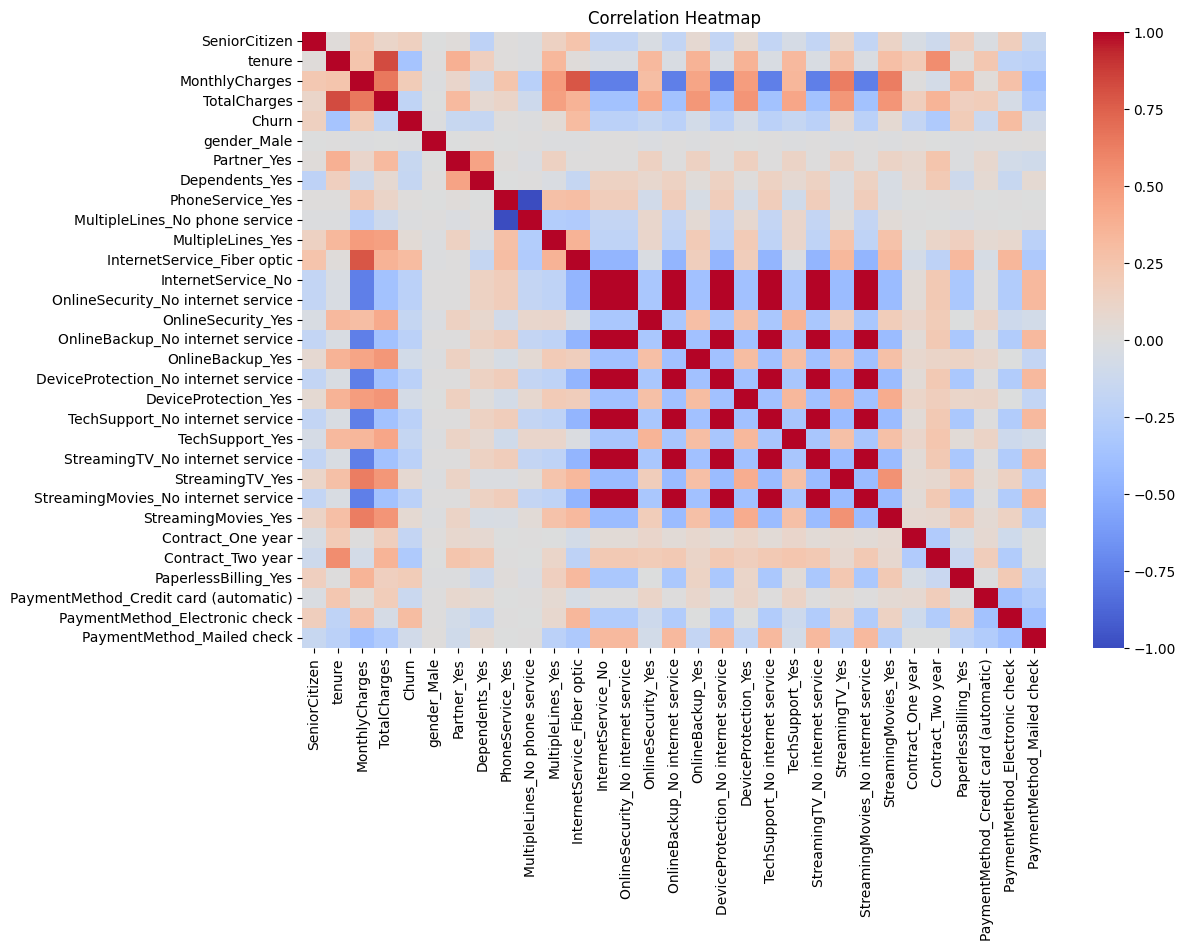

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
df["R_Score"] = pd.qcut(df["tenure"], 4, labels=[1,2,3,4])
df["M_Score"] = pd.qcut(df["TotalCharges"], 4, labels=[1,2,3,4])

df["RFM_Score"] = df["R_Score"].astype(int) + df["M_Score"].astype(int)

print(df[["tenure","TotalCharges","RFM_Score"]].head())


   tenure  TotalCharges  RFM_Score
0       1         29.85          2
1      34       1889.50          6
2       2        108.15          2
3      45       1840.75          6
4       2        151.65          2


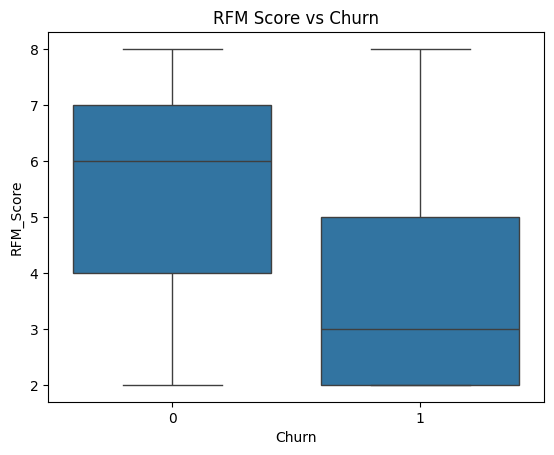

In [10]:
sns.boxplot(x="Churn", y="RFM_Score", data=df)
plt.title("RFM Score vs Churn")
plt.show()


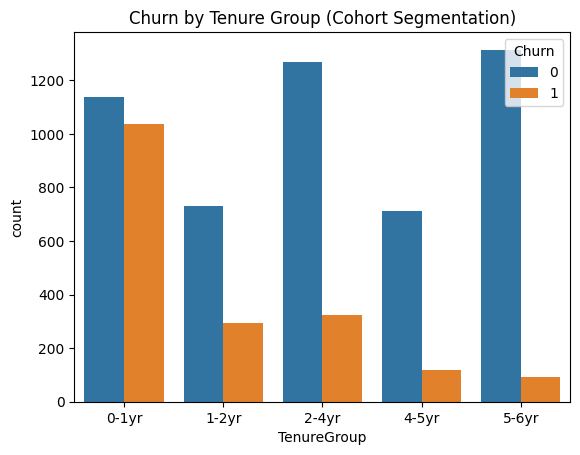

In [11]:
df["TenureGroup"] = pd.cut(df["tenure"],
                          bins=[0,12,24,48,60,72],
                          labels=["0-1yr","1-2yr","2-4yr","4-5yr","5-6yr"])

sns.countplot(x="TenureGroup", hue="Churn", data=df)
plt.title("Churn by Tenure Group (Cohort Segmentation)")
plt.show()


In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test Split Done!")


Train/Test Split Done!


In [16]:
scaler = StandardScaler()

# Drop the 'TenureGroup' column from X_train and X_test before scaling
# as it contains categorical string values ('0-1yr', '1-2yr', etc.)
# that StandardScaler cannot process. The original 'tenure' column is already numeric.
if 'TenureGroup' in X_train.columns:
    X_train_processed = X_train.drop('TenureGroup', axis=1)
    X_test_processed = X_test.drop('TenureGroup', axis=1)
else:
    X_train_processed = X_train
    X_test_processed = X_test

X_train = scaler.fit_transform(X_train_processed)
X_test = scaler.transform(X_test_processed)

In [17]:
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed!")


Model Training Completed!


In [18]:
y_pred = model.predict(X_test)


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy*100, "%")


Model Accuracy: 79.70191625266146 %


In [20]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



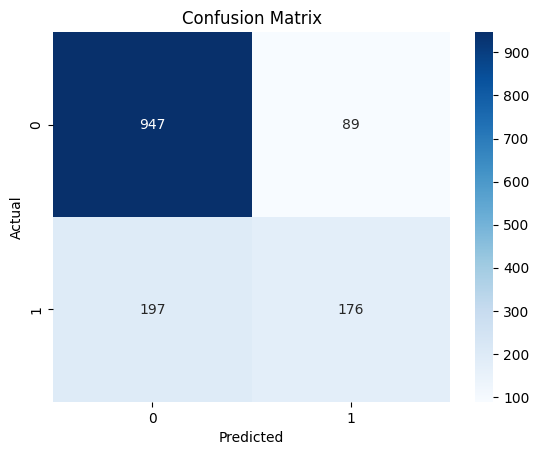

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
